In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

In [30]:
data2 = np.loadtxt("./Data-20260606/10.dat")
data3 = np.loadtxt("./Data-20260606/11.dat")
data4 = np.loadtxt("./Data-20260606/12.dat")
data5 = np.loadtxt("./Data-20260606/13.dat")
data6 = np.loadtxt("./Data-20260606/14.dat")
data7 = np.loadtxt("./Data-20260606/15.dat")
data8 = np.loadtxt("./Data-20260606/16.dat")
data9 = np.loadtxt("./Data-20260606/17.dat")


In [31]:
datasets = [
    (data2, "230 K", 'blue', 's'),
    (data3, "240 K", 'green', '^'),
    (data4, "250 K", 'orange', 'D'),
    (data5, "260 K", 'purple', 'p'),
    (data6, "270 K", 'brown', '*'),
    (data7, "280 K", 'pink', '8'),
    (data8, "290 K", 'black', 'P'),
    (data9, "300 K", 'gray', 'H'),


    # (data9, "300 K", 'olive', 'X'),
    # (data10, "290 K", 'cyan', 'v'),
    # (data11, "280 K", 'magenta', '<'),
    # (data12, "270 K", 'lime', '>'),
    # (data13, "260 K", 'teal', 'o'),
    # (data14, "250 K", 'navy', 's'),
    # (data15, "240 K", 'maroon', '^'),
    # (data16, "230 K", 'silver', 'D'),
    # (data17, "220 K", 'gold', 'p')
]

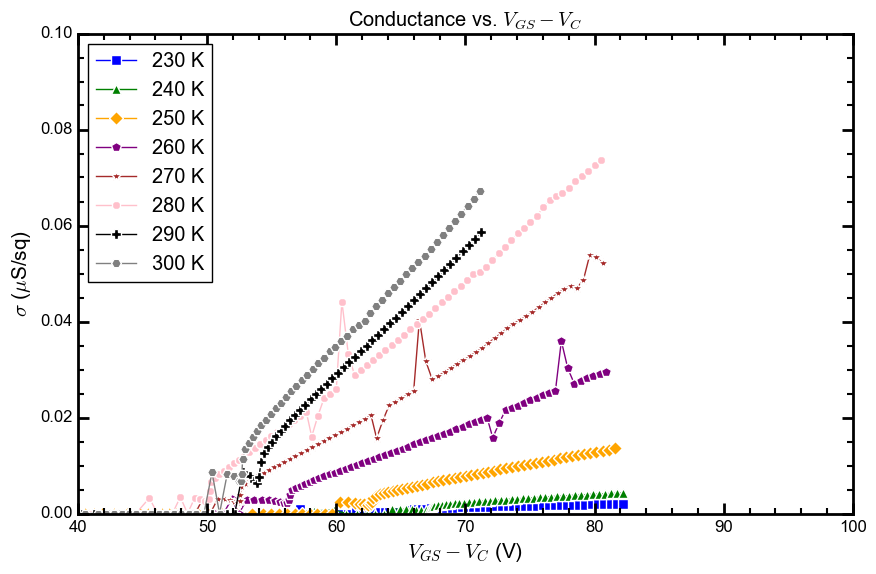

In [32]:
for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5* (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]

    window_size = 1
    window = np.ones(window_size) / window_size

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6
    plt.plot(V_del_smooth, sigma_plot, label=label, color=color, marker=marker, linestyle='-', markeredgecolor="white", markeredgewidth=1, markersize=7)

plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq)")  
plt.xlim(40, 100)
plt.ylim(0, 0.1)
plt.title("Conductance vs. $V_{GS} - V_C$")
plt.legend(numpoints=1, loc='upper left')
plt.show()


230 K: slope = 6.17328e-05, intercept = -0.00300897, R² = 0.9952, V_T = 48.74 V, mu = 1.10e-02 cm²/Vs
240 K: slope = 0.000175502, intercept = -0.00995635, R² = 0.9973, V_T = 56.73 V, mu = 3.12e-02 cm²/Vs
250 K: slope = 0.000511368, intercept = -0.0280634, R² = 0.9992, V_T = 54.88 V, mu = 9.09e-02 cm²/Vs
260 K: slope = 0.000955641, intercept = -0.0487222, R² = 0.9999, V_T = 50.98 V, mu = 1.70e-01 cm²/Vs
270 K: slope = 0.00160288, intercept = -0.0793937, R² = 0.8925, V_T = 49.53 V, mu = 2.85e-01 cm²/Vs
280 K: slope = 0.00215703, intercept = -0.102611, R² = 0.9653, V_T = 47.57 V, mu = 3.83e-01 cm²/Vs
290 K: slope = 0.00263312, intercept = -0.129244, R² = 0.9997, V_T = 49.08 V, mu = 4.68e-01 cm²/Vs
300 K: slope = 0.0027687, intercept = -0.131208, R² = 0.9993, V_T = 47.39 V, mu = 4.92e-01 cm²/Vs


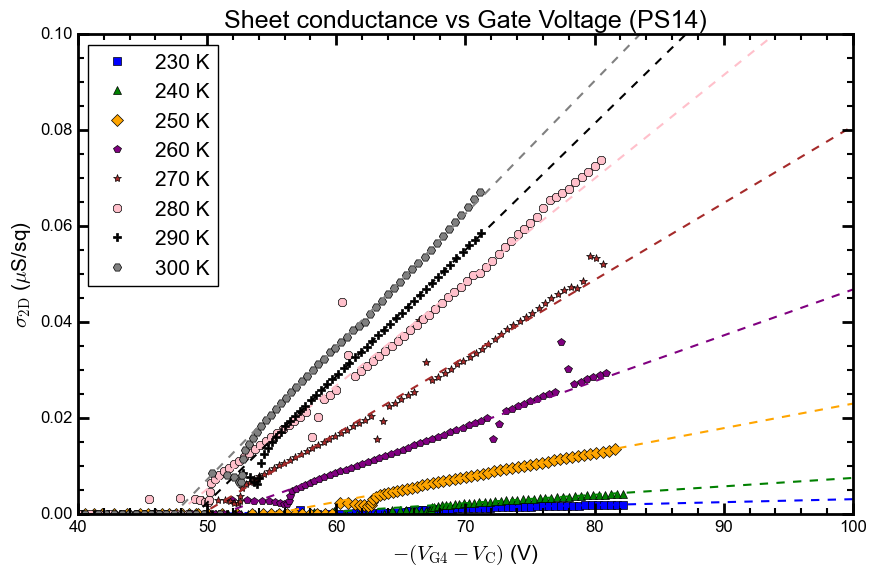

[0.00339947 0.01097472 0.03120035 0.09090993 0.16989165 0.28495575
 0.3834718  0.46810937 0.49221287]
[14.57374279 48.74191287 56.73067344 54.87899568 50.98385218 49.53200288
 47.57033317 49.08393775 47.38973413]


In [33]:

C = 1.8e-9
A = 32e-6
Ci = C / A

mu_vals = np.array([])
V_T_vals = np.array([])

fit_ranges = {
    "300 K": (55, 70),
    "290 K": (55, 70),
    "280 K": (52, 75),
    "270 K": (54, 70),
    "260 K": (58, 70),
    "250 K": (64, 82),
    "240 K": (69, 80),
    "230 K": (70, 80),
}

for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    V_del = -(V_GS - V_C)

    plt.plot(
        V_del,
        sigma * 1e6,
        label=label,
        color=color,
        marker=marker,
        markevery=1,
        ls='None',
        markersize=6,
    )

    fit_vmin, fit_vmax = fit_ranges[label]
    mask = (V_del >= fit_vmin) & (V_del <= fit_vmax)
    x_fit = V_del[mask]
    y_fit = sigma[mask] * 1e6

    if x_fit.size >= 2:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        V_T = -intercept / slope
        mu = slope / Ci * 1e-2
        mu_vals = np.append(mu_vals, mu)
        V_T_vals = np.append(V_T_vals, V_T)
        print(f"{label}: slope = {slope:.6g}, intercept = {intercept:.6g}, R² = {np.corrcoef(x_fit, y_fit)[0, 1]**2:.4f}, V_T = {V_T:.2f} V, mu = {mu:.2e} cm²/Vs")
        x_line = np.linspace(40, 100, 200)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            color=color,
            lw=1.5,
            linestyle='--',
        )

plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)", fontsize=15)
plt.xlim(40, 100)
plt.ylim(0, 0.1)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title("Sheet conductance vs Gate Voltage (PS14)", fontsize=18)
# plt.savefig("vdP_sigma.eps", format='eps')
plt.show()

mu_vals = np.insert(mu_vals,0, 3.39947352e-03)
V_T_vals = np.insert(V_T_vals, 0, 14.57374279)

print(mu_vals)
print(V_T_vals)

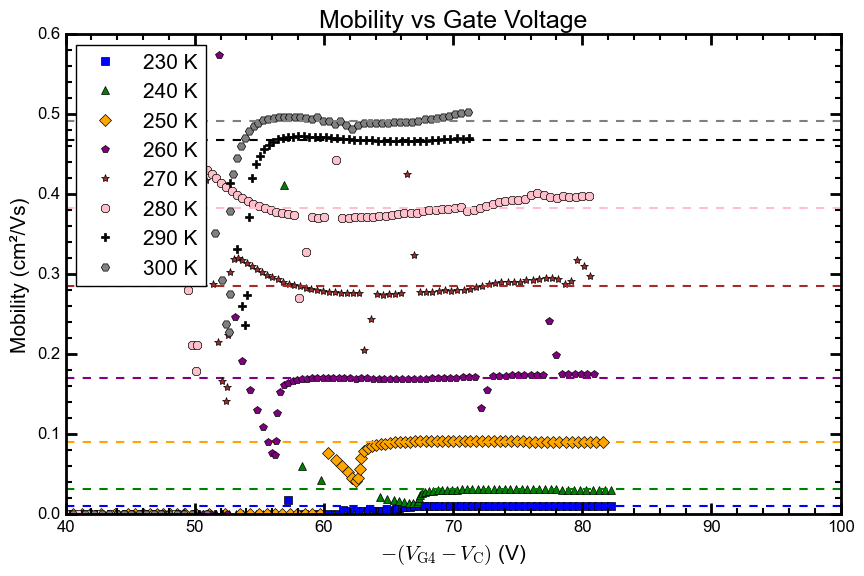

In [36]:
temperature_order = [
    "220 K",
    "230 K",
    "240 K",
    "250 K",
    "260 K",
    "270 K",
    "280 K",
    "290 K",
    "300 K",
]
label_to_index = {temperature: idx for idx, temperature in enumerate(temperature_order)}

for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    V_del = -(V_GS - V_C)

    index = label_to_index[label]
    mu_var = sigma * 1e4 / (Ci * (V_del - V_T_vals[index]))
    plt.plot(
        V_del,
        mu_var,
        label=label,
        color=color,
        marker=marker,
        markevery=1,
        ls='None',
        markersize=6,
    )
    plt.axhline(mu_vals[index], color=color, ls='--', lw=1.5)
plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"Mobility (cm²/Vs)", fontsize=15)
plt.xlim(40, 100)
plt.ylim(0, 0.6)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title("Mobility vs Gate Voltage", fontsize=18)
plt.show()



C:\Users\lugwi\AppData\Local\Temp\ipykernel_7260\3072967997.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, max(mu_vals)*1.2)


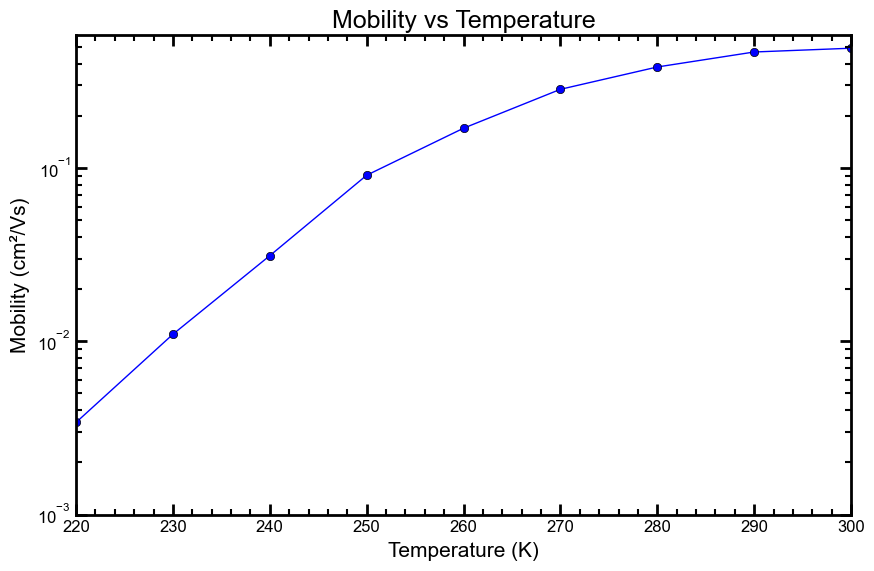

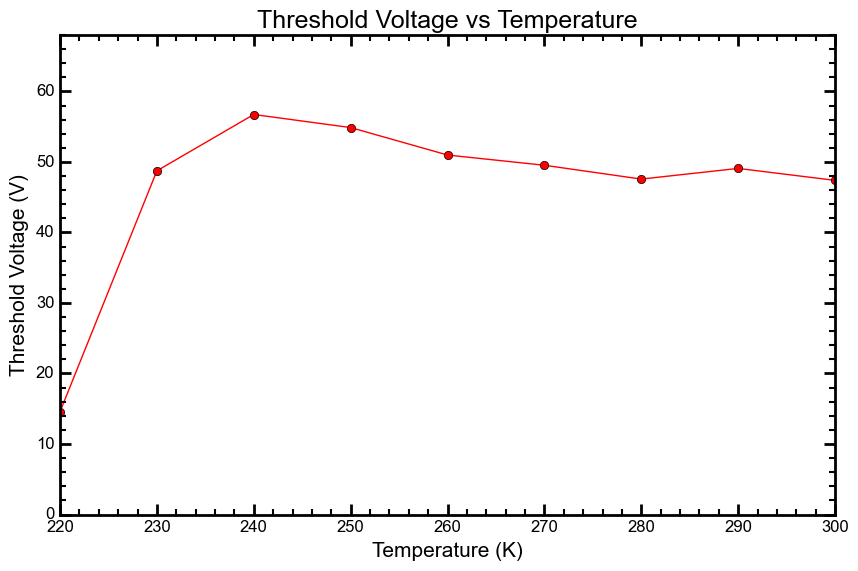

In [35]:
T_vals = np.array([220, 230, 240, 250, 260, 270, 280, 290, 300])
plt.semilogy(T_vals, mu_vals, marker='o', color='blue')
plt.xlabel("Temperature (K)", fontsize=15)
plt.ylabel("Mobility (cm²/Vs)", fontsize=15)
plt.title("Mobility vs Temperature", fontsize=18)
plt.xlim(220, 300)
plt.ylim(0, max(mu_vals)*1.2)
plt.show()

plt.plot(T_vals, V_T_vals, marker='o', color='red')
plt.xlabel("Temperature (K)", fontsize=15)
plt.ylabel("Threshold Voltage (V)", fontsize=15)
plt.title("Threshold Voltage vs Temperature", fontsize=18)
plt.xlim(220, 300)
plt.ylim(0, max(V_T_vals)*1.2)
plt.show()
